**Section 2: Location and Investment Hotspots**

Importing relevant Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

Loading the cleaned dataset from our last notebook

In [2]:
data = pd.read_csv('data/lagos_real_estate_cleaned_final.csv')
data.columns

Index(['Unnamed: 0', 'listing_url', 'title', 'location', 'property_type',
       'beds', 'baths', 'status', 'post-date-absolute', 'price(millions_NGN)',
       'log_price_millions_NGN', '24hrs Power', '30kva generator',
       '5kva inverter', 'Balcony', 'BQ', 'Car Park', 'CCTV',
       'Children Playground', 'Fitted Bathrooms', 'Fitted Kitchen',
       'Fully Furnished', 'Gated Estate', 'Gym', 'Home Automation',
       'Home Entertainment Unit', 'Jacuzzi', 'Maid's Room', 'Rooftop Terrace',
       'Swimming Pool', 'Walk-in Closet', 'WiFi', 'Golf Course View',
       'Private Elevator', 'Study', 'Cinema', 'Garden', 'Water Front',
       'Private Cinema', 'Water View', 'Football Pitch', 'Tennis Court',
       'Sauna'],
      dtype='object')

In [3]:
data = data.drop(columns='Unnamed: 0')
data.head()

,listing_url,title,location,property_type,beds,baths,status,post-date-absolute,price(millions_NGN),log_price_millions_NGN,...,Private Elevator,Study,Cinema,Garden,Water Front,Private Cinema,Water View,Football Pitch,Tennis Court,Sauna
0,https://cwlagos.com/property/3-bedroom-apartme...,3 Bedroom Apartment + BQ,Banana Island,Apartment,3.0,3.0,Rent,2025-06-21,30.000,3.401197,...,1,0,1,0,0,0,0,0,0,0
1,https://cwlagos.com/property/terrace-for-sale-...,TERRACE IN BANANA ISLAND IKOYI,Banana Island,Terraced,5.0,5.0,Sale,2025-06-21,3616.925,8.193379,...,0,0,0,0,0,0,0,0,0,0
2,https://cwlagos.com/property/brand-new-5-bedro...,Brand New 5 Bedroom Semi-Detached House with W...,Banana Island,Semi Detached,5.0,5.0,Sale,2024-11-18,2170.155,7.682554,...,1,0,0,0,1,0,1,0,0,0
3,https://cwlagos.com/property/six-bedroom-fully...,Six Bedroom Fully Detached house in Banana Island,Banana Island,Detached,0.0,0.0,Sale,2025-06-21,5200.000,8.556414,...,0,0,1,0,0,0,0,0,0,0
4,https://cwlagos.com/property/6-bedroom-detache...,6-Bedroom Detached House in Banana Island,Banana Island,Detached,6.0,6.0,Sale,2025-09-19,7233.850,8.886527,...,0,0,0,0,0,0,0,0,0,0


**Question 1 - \
Which locations have the highest median property prices?**

In [28]:
# Grouping locations by median prices
group_1 = data.groupby('location')['price(millions_NGN)'].median()
group_1.sort_values(ascending=False).head(10)

location
Banana Island    1059.349475
Osapa             495.000000
Chevron           420.000000
Ikate             240.000000
Lekki             230.000000
VI                 55.000000
Ikoyi              50.000000
Oniru              25.000000
Name: price(millions_NGN), dtype: float64

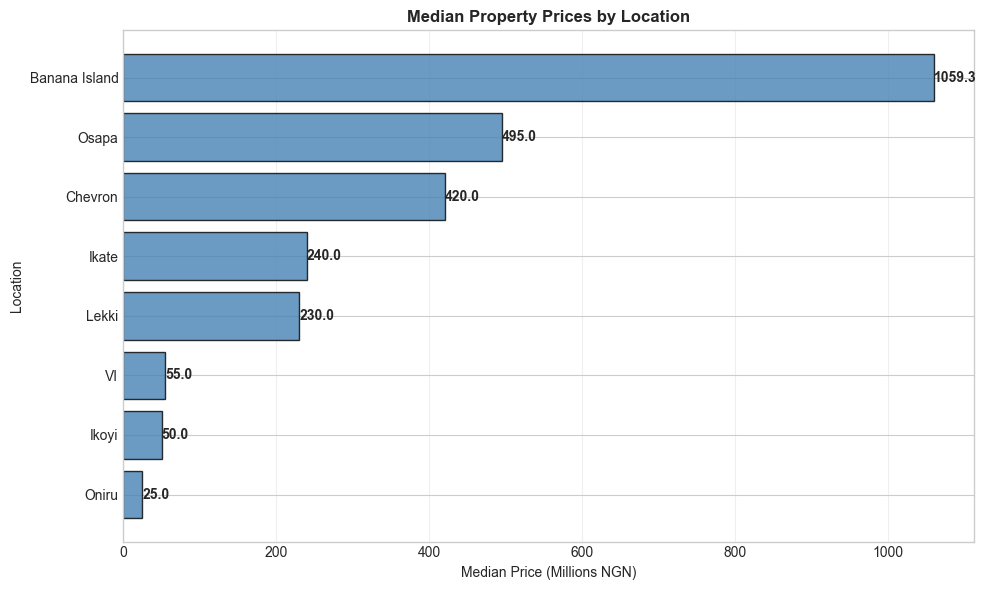

In [33]:
# Sort for better visual interpretation
group_1_sorted = group_1.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    group_1_sorted.index,
    group_1_sorted.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

plt.xlabel('Median Price (Millions NGN)')
plt.ylabel('Location')
plt.title('Median Property Prices by Location', fontweight='bold')

plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, group_1_sorted.values):
    plt.text(
        val,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}',
        va='center',
        ha='left',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**From the above, we can conclude that "Banana Island" has the highest median property prices, with "Osapa" and "Chevron" coming second and third respectively.**

\
**Question 2 - \
Which locations have the lowest median property prices?**

In [29]:
# Grouping locations by median prices
group_1 = data.groupby('location')['price(millions_NGN)'].median()
group_1.sort_values(ascending=True).head(10)

location
Oniru              25.000000
Ikoyi              50.000000
VI                 55.000000
Lekki             230.000000
Ikate             240.000000
Chevron           420.000000
Osapa             495.000000
Banana Island    1059.349475
Name: price(millions_NGN), dtype: float64

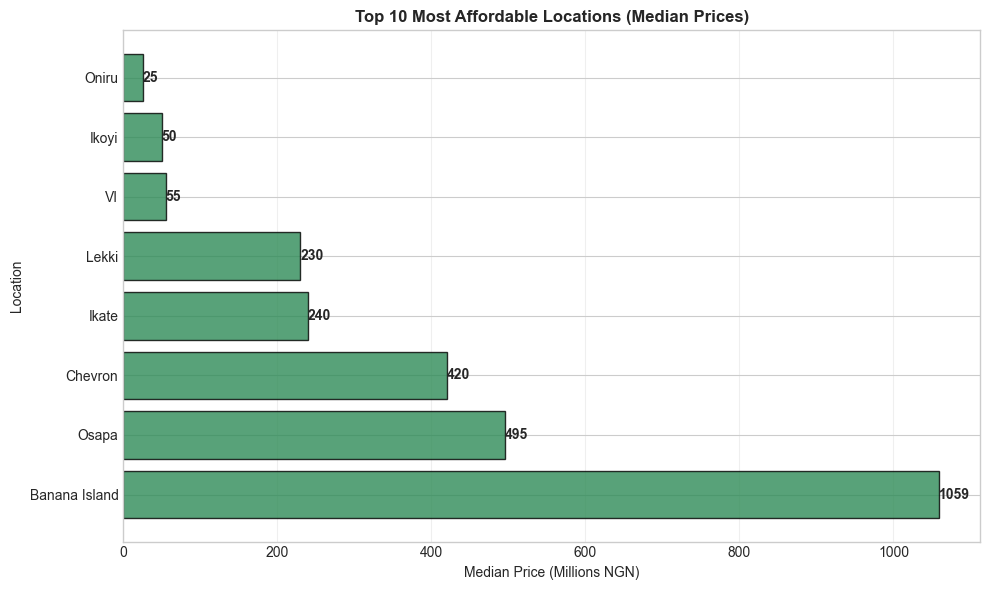

In [32]:
group_sorted = group_1.sort_values(ascending=False)

# Take top 10 cheapest locations
top10 = group_sorted.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top10.index,
    top10.values,
    color='seagreen',
    edgecolor='black',
    alpha=0.8
)

plt.xlabel('Median Price (Millions NGN)')
plt.ylabel('Location')
plt.title('Top 10 Most Affordable Locations (Median Prices)', fontweight='bold')

plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, top10.values):
    plt.text(
        val,
        bar.get_y() + bar.get_height()/2,
        f'{val:.0f}',
        va='center',
        ha='left',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**From the above, we can conclude that "Oniru" has the lowest median property prices, with "Ikoyi" and "VI" coming second and third respectively.**

\
**Question 3 -\
Which locations have the highest number of listings (investment concentration)?**

In [30]:
# Grouping location by number of property listings
group_2 = data.groupby('location')['property_type'].count()
group_2.sort_values(ascending=False)

location
Lekki            266
Ikoyi            252
VI               148
Ikate             56
Oniru             56
Osapa             30
Banana Island     20
Chevron           19
Name: property_type, dtype: int64

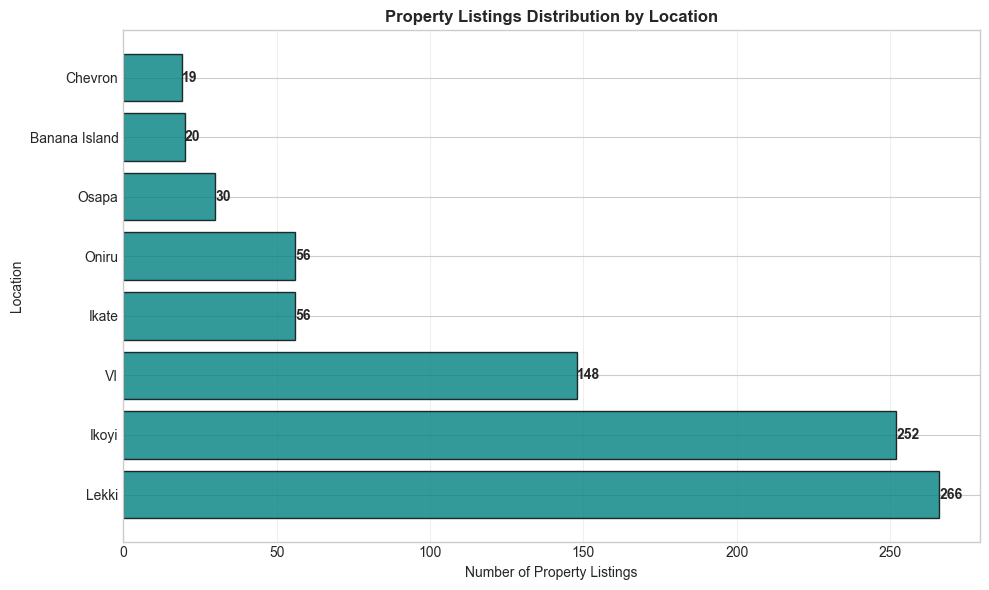

In [35]:
# Sort values (highest to lowest for better interpretation)
group_sorted = group_2.sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    group_sorted.index,
    group_sorted.values,
    color='teal',
    edgecolor='black',
    alpha=0.8
)

plt.xlabel('Number of Property Listings')
plt.ylabel('Location')
plt.title('Property Listings Distribution by Location', fontweight='bold')

plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, group_sorted.values):
    plt.text(
        val,
        bar.get_y() + bar.get_height()/2,
        f'{int(val)}',
        va='center',
        ha='left',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**From the above, we can conclude that "Lekki" has the highest number of listings, while "Ikoyi" and "VI" are second and third respectively.**

\
**Question 4 -\
How does price per bedroom vary across major locations?**

In [37]:
# Determining major locations
group_4 = group_2 / sum(group_2) * 100
group_4.sort_values(ascending=False).head(10)

location
Lekki            31.404959
Ikoyi            29.752066
VI               17.473436
Ikate             6.611570
Oniru             6.611570
Osapa             3.541913
Banana Island     2.361275
Chevron           2.243211
Name: property_type, dtype: float64

From the above "Lekki", "Ikoyi" and "VI", make up approximately 31%, 30% and 17% of our listings respectively, while the other locations make up 21% collectively. Therefore, we would be considering this three mentioned as Major Locations.

In [9]:
major_locations = ['Lekki', 'Ikoyi', 'VI']
data2 = data[data['location'].isin(major_locations)]
data2['location'].unique()

array(['Lekki', 'Ikoyi', 'VI'], dtype=object)

In [40]:
# Grouping Median price per bedrooms and major locations
group_5 = data2.groupby(['location', 'beds'])['price(millions_NGN)'].median()
group_5.unstack()

beds,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,9.0,11.0,14.0,47.0
location,,,,,,,,,,,,
Ikoyi,38.5,15.00,31.0,40.0,72.3385,500.0,2893.54,NaN,274.8863,NaN,NaN,5000.0
Lekki,45.0,31.25,57.5,60.0,240.0000,450.0,975.00,NaN,NaN,NaN,NaN,NaN
VI,60.0,200.00,250.0,35.0,195.0000,47.5,107.50,50.0,2400.0000,2400.0,1300.0,NaN


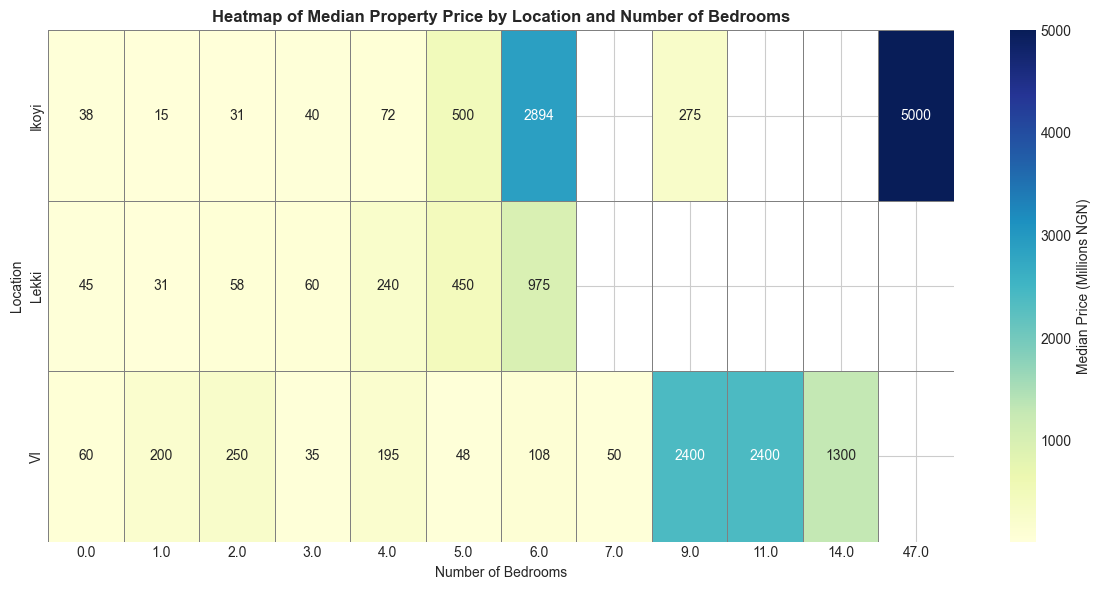

In [46]:
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.heatmap(
    group_5.unstack(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={'label': 'Median Price (Millions NGN)'}
)

plt.title("Heatmap of Median Property Price by Location and Number of Bedrooms",
          fontweight='bold')

plt.xlabel("Number of Bedrooms")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

Using Log Transformation for better visualization

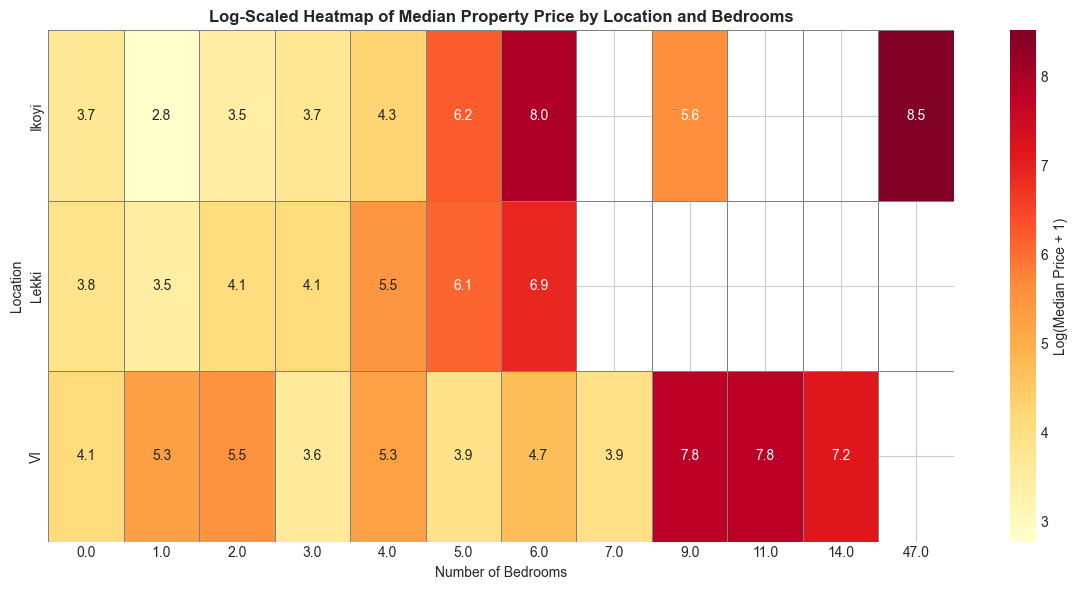

In [47]:
import numpy as np

plt.figure(figsize=(12, 6))

sns.heatmap(
    np.log1p(group_5.unstack()),   # log transform to reduce skew
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={'label': 'Log(Median Price + 1)'}
)

plt.title("Log-Scaled Heatmap of Median Property Price by Location and Bedrooms",
          fontweight='bold')

plt.xlabel("Number of Bedrooms")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

**The heatmap reveals strong price stratification across Lagos real estate markets. Ikoyi and Victoria Island exhibit extreme price escalation for larger bedroom units, indicating luxury-driven demand. In contrast, Lekki shows more stable and moderate pricing behavior, suggesting a more balanced and competitive mid-income housing market.**